In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# CIFAR-10 (32x32)

# Transforms definitions
train_transform = transforms.Compose([
    transforms.Resize(224), # upscale [32,32] -> [224, 224]
    transforms.RandomHorizontalFlip(), # change right and left
    transforms.ColorJitter(),
    transforms.RandomRotation(15),
    transforms.ToTensor(), # 0-255 -> 0-1.0
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5)) # mean(s) are all 0.5, std are all 0.5
])

test_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Dataset loading
os.makedirs('./data', exist_ok=True)
train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# DataLoader definitinos
BATCH_SIZE = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True # GPU transportation speed up
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

shape torch.Size([128, 3, 224, 224])


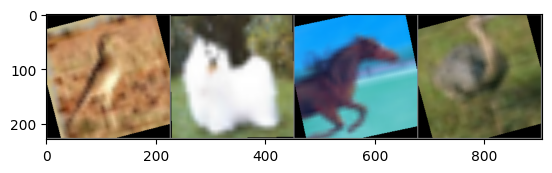

labels : bird dog horse bird


In [3]:
def imshow(img):
    img = img / 2 + 0.5 # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.show()

# get 1 batch
dataiter = iter(train_loader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print('shape', images.shape)
imshow(torchvision.utils.make_grid(images[:4]))
print(f'labels : {" ".join(classes[labels[j]] for j in range(4))}')

In [4]:
import wandb

hyper_params={
    'archtecture': 'tiny-vit',
    'dataset': 'CIFAR-10',
    'epochs': 100,
    'learning_rate': 1e-3,
    'img_size':224,
    'patch_size':16,
    'in_chans':3,
    'num_classes':10,
    'embed_dim':192,
    'depth':6,
    'num_heads':6,
    'mlp_ratio':4, 
    'qkv_bias': True,
    'drop_rate': 0.,
    'attn_drop_rate': 0.,
    'drop_path_rate': 0.2,
    'weight_decay': 0.05,
    'opt_name': 'adamw',
    'sched_name': 'cosine'
}

wandb.init(
    project='vit-difar10-project-Tmax100',
    config=hyper_params
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: sasatake-harumo (sasatake-harumo-techmagic) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
from vit import VisionTransformer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VisionTransformer(
    img_size=wandb.config.img_size,
    patch_size=wandb.config.patch_size,
    in_chans=wandb.config.in_chans,
    num_classes=wandb.config.num_classes,
    embed_dim=wandb.config.embed_dim,
    depth=wandb.config.depth,
    num_heads=wandb.config.num_heads,
    mlp_ratio=wandb.config.mlp_ratio, # in mlp use 4x hedden dim
    qkv_bias=wandb.config.qkv_bias,
    drop_rate=wandb.config.drop_rate,
    drop_path_rate=wandb.config.drop_path_rate
).to(device)

print(f'Model created and moved to {device}')

Model created and moved to cuda


In [6]:
# define loss function
criterion = torch.nn.CrossEntropyLoss()

# optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=wandb.config.learning_rate, weight_decay=wandb.config.weight_decay)

# lr scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=wandb.config.epochs)

In [7]:
# training setting
# AMP mix presicion
scaler = torch.amp.GradScaler()

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # mix precision
        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        # backpropagation with scalled grad
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return total_loss / len(dataloader), 100. * correct / total
            

In [8]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(dataloader), 100. * correct / total

In [9]:
# train
EPOCHS = wandb.config.epochs

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    scheduler.step() # update next learning rate

    metrics = {
        'epoch': epoch+1,
        'train/loss': train_loss,
        'train/acc' : train_acc,
        'test/loss' : test_loss,
        'test/acc'  : test_acc,
        'learning_rate' : optimizer.param_groups[0]['lr']
    }

    wandb.log(metrics)
    print(f'epoch: {metrics['epoch']}, train loss: {metrics['train/loss']}, train acc: {metrics['train/acc']}, test loss: {metrics['test/loss']}, test acc: {metrics['test/acc']}')

wandb.finish()

epoch: 1, train loss: 1.861853335519581, train acc: 30.446, test loss: 1.6393030006674272, test acc: 38.21
epoch: 2, train loss: 1.5730468537801368, train acc: 41.88, test loss: 1.540667241132712, test acc: 43.49
epoch: 3, train loss: 1.4332840518878245, train acc: 47.562, test loss: 1.4271259760554833, test acc: 46.34
epoch: 4, train loss: 1.3440741004846286, train acc: 50.894, test loss: 1.322942181478573, test acc: 52.07
epoch: 5, train loss: 1.2562253517872841, train acc: 54.506, test loss: 1.2623578264743467, test acc: 53.92
epoch: 6, train loss: 1.180955197805029, train acc: 57.124, test loss: 1.177075515065012, test acc: 57.43
epoch: 7, train loss: 1.1191514254835866, train acc: 59.74, test loss: 1.1021791764452487, test acc: 59.44
epoch: 8, train loss: 1.0664446649648953, train acc: 61.528, test loss: 1.0772764826122718, test acc: 60.9
epoch: 9, train loss: 1.0150790594118027, train acc: 63.408, test loss: 1.0165495985670934, test acc: 62.88
epoch: 10, train loss: 0.97392469339

epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇████
learning_rate,█████████▇▇▇▇▇▇▆▆▆▆▅▅▄▄▄▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
test/acc,▁▂▃▄▄▆▆▆▆▆▇▇▇▇▇▇▇███████████████████████
test/loss,█▆▅▃▃▃▂▂▂▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▃▄▄▄▄▄▄▄▅▅▅▅▅▅
train/acc,▁▂▃▃▄▅▅▅▅▅▆▇▇▇▇▇▇▇▇█████████████████████
train/loss,█▆▆▆▅▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
learning_rate,0
test/acc,80.75
test/loss,1.07727
train/acc,99.592
